Import Libraries

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [48]:
df = pd.read_csv("netflix_titles.csv")

In [49]:
print(df.shape)
print(df.info())
df.head()

(8807, 12)
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB
None


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [50]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [ ]:
# Fill categorical missing values with 'Unknown'
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['date_added'].fillna('Unknown', inplace=True)
df['rating'].fillna('Not Rated', inplace=True)
df['duration'].fillna('Unknown', inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_16424\1137033027.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['director'].fillna('Unknown', inplace=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_16424\1137033027.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment usi

0          90 min
1       2 Seasons
2        1 Season
3        1 Season
4       2 Seasons
          ...    
8802      158 min
8803    2 Seasons
8804       88 min
8805       88 min
8806      111 min
Name: duration, Length: 8807, dtype: str

In [52]:
# Clean duration text
df_shows['seasons'] = (
    df_shows['duration']
    .str.replace(' Season','', regex=False)
    .str.replace(' Seasons','', regex=False)
    .str.strip()
)

# Convert to numeric safely
df_shows['seasons'] = pd.to_numeric(df_shows['seasons'], errors='coerce')

# Keep as nullable integer type (best practice)
df_shows['seasons'] = df_shows['seasons'].astype('Int64')


In [53]:
print(df_shows['seasons'].value_counts().head(10))

seasons
1    1793
Name: count, dtype: Int64


In [ ]:
df.head()

In [54]:
print("Average movie length (minutes):", df_movies['duration_minutes'].mean())
print("Average number of seasons:", df_shows['seasons'].mean())


Average movie length (minutes): 99.57718668407311
Average number of seasons: 1.0


In [55]:
# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Extract year and month
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month


Movies vs TV Shows Patterns

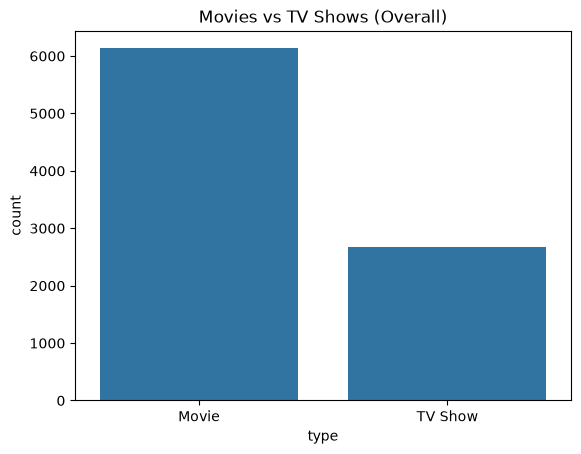

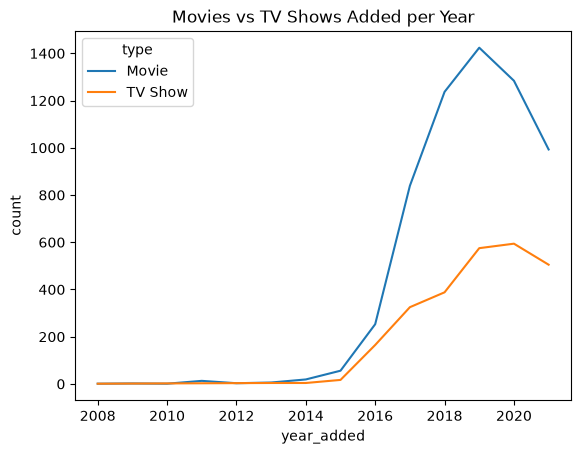

In [56]:
# Overall ratio
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows (Overall)")
plt.show()

# Ratio by year
type_by_year = df.groupby(['year_added','type']).size().reset_index(name='count')
sns.lineplot(x='year_added', y='count', hue='type', data=type_by_year)
plt.title("Movies vs TV Shows Added per Year")
plt.show()


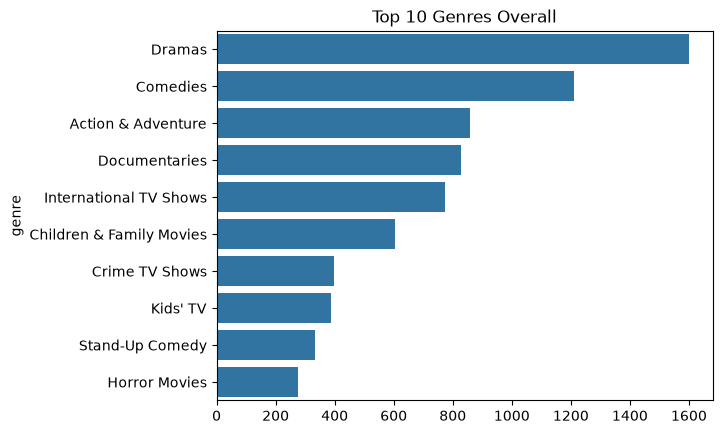

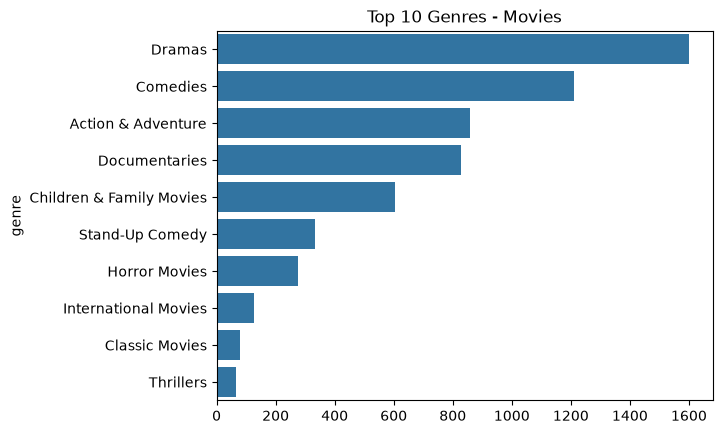

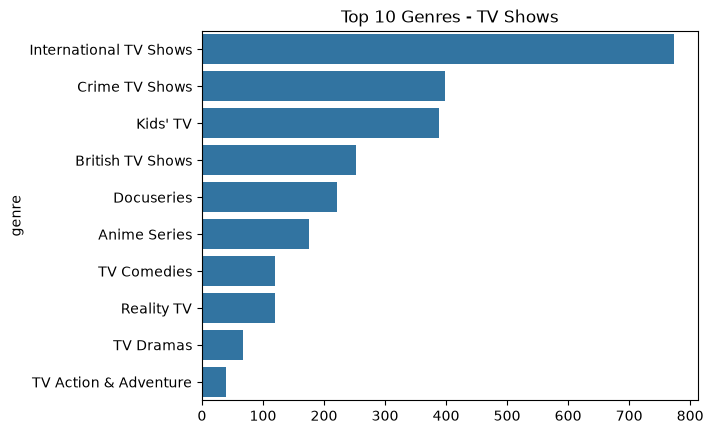

In [57]:
# Extract first genre
df['genre'] = df['listed_in'].str.split(',').str[0]

# Top genres overall
top_genres = df['genre'].value_counts().head(10)
sns.barplot(y=top_genres.index, x=top_genres.values)
plt.title("Top 10 Genres Overall")
plt.show()

# Top genres for Movies
top_movie_genres = df[df['type']=='Movie']['genre'].value_counts().head(10)
sns.barplot(y=top_movie_genres.index, x=top_movie_genres.values)
plt.title("Top 10 Genres - Movies")
plt.show()

# Top genres for TV Shows
top_show_genres = df[df['type']=='TV Show']['genre'].value_counts().head(10)
sns.barplot(y=top_show_genres.index, x=top_show_genres.values)
plt.title("Top 10 Genres - TV Shows")
plt.show()


Top Genres Lifecycle

In [58]:
# Create decade column from release_year
df['decade'] = (df['release_year'] // 10) * 10

In [59]:
# Extract first genre for simplicity
df['genre'] = df['listed_in'].str.split(',').str[0]

In [60]:
# Count genres by decade
genre_decade = df.groupby(['decade','genre']).size().reset_index(name='count')

# Keep only top genres overall
top_genres = genre_decade.groupby('genre')['count'].sum().nlargest(8).index
genre_decade_top = genre_decade[genre_decade['genre'].isin(top_genres)]

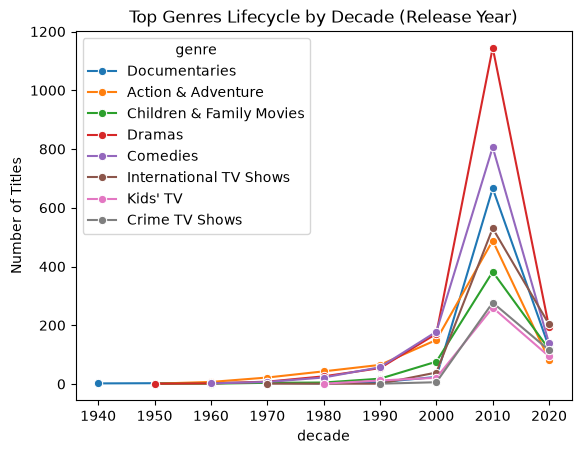

In [61]:
sns.lineplot(x='decade', y='count', hue='genre', data=genre_decade_top, marker='o')
plt.title("Top Genres Lifecycle by Decade (Release Year)")
plt.ylabel("Number of Titles")
plt.show()

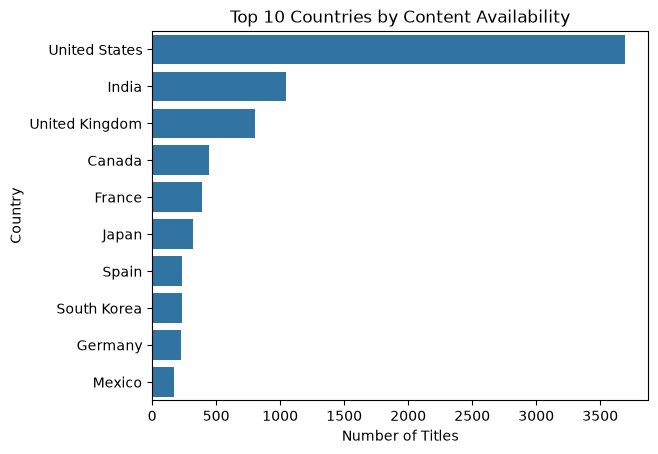

In [63]:
# Split multiple countries into separate rows
df_country = df.assign(country=df['country'].str.split(',')).explode('country')
df_country['country'] = df_country['country'].str.strip()

# Count titles per country
country_counts = df_country['country'].value_counts().head(10)

sns.barplot(y=country_counts.index, x=country_counts.values)
plt.title("Top 10 Countries by Content Availability")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()


Catch-up Window by Country

In [64]:
# Ensure datetime conversion
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Calculate lag in days
df['catchup_days'] = (df['date_added'].dt.year - df['release_year']) * 365


In [65]:
# Split multiple countries into separate rows
df_country = df.assign(country=df['country'].str.split(',')).explode('country')
df_country['country'] = df_country['country'].str.strip()


country
Liechtenstein    19710.000000
East Germany     17885.000000
West Germany     14746.000000
Soviet Union     11801.666667
Ethiopia         10220.000000
Burkina Faso     10220.000000
Algeria           5840.000000
Bahamas           5110.000000
Hong Kong         5019.619048
Poland            3970.487805
Name: catchup_days, dtype: float64


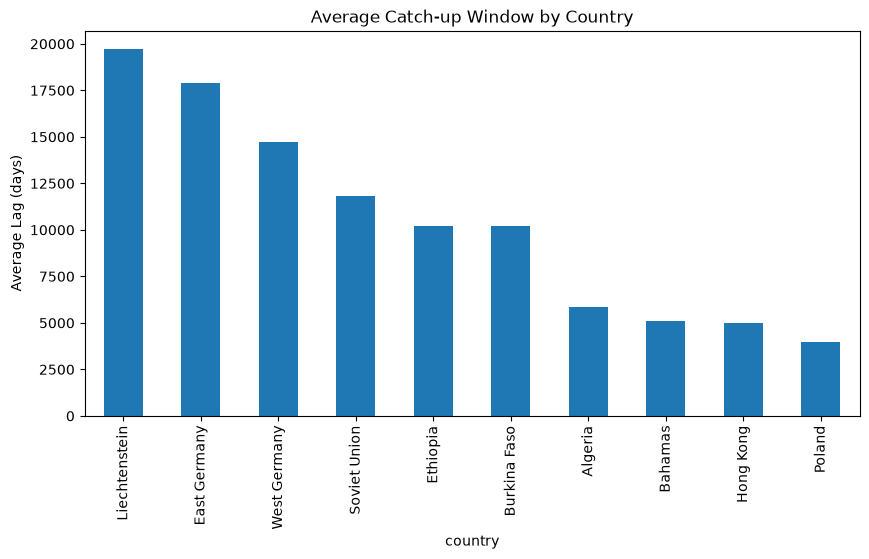

In [66]:
country_catchup = (
    df_country.groupby('country')['catchup_days']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(country_catchup)

country_catchup.plot(kind='bar', figsize=(10,5))
plt.title("Average Catch-up Window by Country")
plt.ylabel("Average Lag (days)")
plt.show()
